# PHYS3934: Computational Physics Assignment, 2026

## Instructions
Provide written answers including explanations, where required, for all questions below. Questions that require writing or modifying existing code will include a subquestion asking you to provide a listing of the code. While code upload questions are not assigned marks directly, the code can be marked in combination with the questions that use the output of the code. Your provided code may be tested by markers: it should run without error and reproduce the outputs (e.g., figures) that you present in your assignment. While it is acceptable to discuss your assignment with other students, you must write your own version of each answer. For the coding component, this means the new working parts of the code needed for a problem must be your own work.

## The Dancing T-Handle

The video below shows a nice example of unstable motion of a dancing T-handle. You can watch a full video  [here](https://www.youtube.com/watch?v=1n-HMSCDYtM).  

In [1]:
from IPython.display import Video
Video("t-handle.mp4", embed=True)

This 'T-handle' is set spinning about a particular axis in zero gravity. The object spins for a while, and then flips its axis of rotation. The angular momentum of the T-handle is conserved, so after flipping, the handle is spinning in the opposite sense. The motion can be modelled using the Euler equations for free rotation of a rigid body (not to be confused with the Euler solver!):

$$A\frac{d\omega_{1}}{dt}=(B-C)\omega_{2}\omega_{3}  \tag{1}$$
$$B\frac{d\omega_{2}}{dt}=(C-A)\omega_{3}\omega_{1}  \tag{2}$$
$$C\frac{d\omega_{3}}{dt}=(A-B)\omega_{1}\omega_{2}  \tag{3}$$


where $\omega_{1}$, $\omega_{2}$, and $\omega_{3}$ are the angular velocities about the three principal axes of the body, and A, B, and C are the moments of inertia for rotation about those axes. The principal axes are fixed in the body, so Eqs (1)-(3) describe the motion in the moving frame of reference.

It is possible to show from these equations that for an object with three different principal moments of inertia, $A<B<C$, pure rotation about the axis corresponding to the "intermediate" moment of inertia, B, is unstable. This instability is exhibited by the T-handle. In this assignment, we will model the instability numerically.

### Question 1: Conserved Quantities and Non-Dimensionalisation (6 points)

**(a) [2 points]** The kinetic energy, K, and the magnitude of the angular momentum, L, of the body are given by:
$$K=\frac{1}{2}A\omega_{1}^{2}+\frac{1}{2}B\omega_{2}^{2}+\frac{1}{2}C\omega_{3}^{2}   \tag{4}$$
and
$$L^{2}=A^{2}\omega_{1}^{2}+B^{2}\omega_{2}^{2}+C^{2}\omega_{3}^{2}  \tag{5}$$
Using Eqs (1)-(3), show that K and L are conserved.


<span style="color:magenta">*(Workspace for Answers)*</span>

Kinetic energy first:
$$
\begin{align*}
    \frac{dK}{dt} &= \frac{1}{2}A\frac{d\omega_1^2}{dt} + \frac{1}{2}B\frac{d\omega_2^2}{dt} + \frac{1}{2}C\frac{d\omega_3^2}{dt} \\
    &= A\frac{d\omega_1}{dt} \omega_1 + B\frac{d\omega_2}{dt}\omega_2 + C\frac{d\omega_3}{dt}\omega_3 \\
    &= (B-C)\omega_1\omega_2\omega_3 + (C-A)\omega_1\omega_2\omega_3 + (A-B)\omega_1\omega_2\omega_3 \\
    &= (B - C + C - A + A - B)\omega_1\omega_2\omega_3 \\
    &= 0
\end{align*}
$$

A similar process for angular momentum
$$
\begin{align*}
    \frac{dL}{dt} &= \frac{d}{dt}(A^2\omega_1^2 + B^2\omega_2^2 + C^2\omega_3^2)^{1/2} \\
    &= \frac{1}{2}(A^2\omega_1^2 + B^2\omega_2^2 + C^2\omega_3^2)^{-1/2}\frac{d}{dt}(A^2\omega_1^2 + B^2\omega_2^2 + C^2\omega_3^2) \\
    &= \frac{1}{2L} \left( 2A^2\frac{d\omega_1}{dt}\omega_1 + 2B^2\frac{d\omega_2}{dt}\omega_2 + 2C^2\frac{d\omega_3}{dt}\omega_3 \right) \\
    &= \frac{1}{L} \left( A(B-C)\omega_1\omega_2\omega_3 + B(C-A)\omega_1\omega_2\omega_3 + C(A-B)\omega_1\omega_2\omega_3 \right) \\
    &= \frac{1}{L}  (AB-AC + BC - AB + AC - AB)\omega_1\omega_2\omega_3  \\
    &= 0
\end{align*}
$$

Thus both kinetic energy and maginitude of angular momenum are conserved in time in this closed system.

**(b) [2 points]** By introducing a scale factor, $t_{s}$, for time, show that the Euler equations can be written in the non-dimensional form:
$$a\frac{d\overline{\omega}_{1}}{d\overline{t}}=(b-1)\overline{\omega}_{2}\overline{\omega}_{3}   \tag{6}$$
$$b\frac{d\overline{\omega}_{2}}{d\overline{t}}=(1-a)\overline{\omega}_{3}\overline{\omega}_{1}   \tag{7}$$
$$\frac{d\overline{\omega}_{3}}{d\overline{t}}=(a-b)\overline{\omega}_{1}\overline{\omega}_{2}   \tag{8}$$
where the bars denote dimensionless quantities, with $a=A/C$ and $b=B/C$.


<span style="color:magenta">*(Workspace for Answers)*</span>

$\omega$ is in units of $\mathrm{rad \cdot s^{-1}}$ so we choose $\omega_s = 1/t_s$. Then

$$
\begin{align*}
    \bar \omega_{i} = \frac{\omega_i}{\omega_s} \implies \frac{d\omega_i}{dt} = \frac{\omega_s}{t_s}\frac{d\bar \omega_i}{d\bar t} \tag{*}
\end{align*}
$$

Then into the euler equations we have
$$
\begin{align*}
    A\frac{d\omega_{1}}{dt}=(B-C)\omega_{2}\omega_{3} \rightarrow \frac{A}{C} \frac{\omega_s}{t_s}\frac{d\bar\omega_1}{d\bar t} &= (\frac{B}{C} - \frac{C}{C})\bar\omega_2\bar\omega_3\omega_s^2 \\
    a\frac{1}{\omega_st_s}\frac{d\bar\omega_1}{d\bar t} &= (b - 1)\bar\omega_2\bar\omega_3 \\
    a\frac{d\bar\omega_1}{d\bar t} &= (b - 1)\bar\omega_2\bar\omega_3 \tag{6}\\
    \\
    B\frac{d\omega_{2}}{dt}=(C-A)\omega_{3}\omega_{1} \rightarrow \frac{B}{C} \frac{\omega_s}{t_s}\frac{d\bar\omega_2}{d\bar t} &= (\frac{C}{C} - \frac{A}{C})\bar\omega_1\bar\omega_3\omega_s^2 \\
    b\frac{1}{\omega_st_s}\frac{d\bar\omega_2}{d\bar t} &= (1 - a)\bar\omega_3\bar\omega_1 \\
    b\frac{d\bar\omega_2}{d\bar t} &= (1-a)\bar\omega_3\bar\omega_1 \tag{7}\\
    \\
    C\frac{d\omega_{3}}{dt}=(A-B)\omega_{1}\omega_{2} \rightarrow \frac{C}{C} \frac{\omega_s}{t_s}\frac{d\bar\omega_3}{d\bar t} &= (\frac{A}{C} - \frac{B}{C})\bar\omega_1\bar\omega_2\omega_s^2 \\
    \frac{1}{\omega_st_s}\frac{d\bar\omega_3}{d\bar t} &= (a - b)\bar\omega_1\bar\omega_2 \\
    \frac{d\bar\omega_3}{d\bar t} &= (a-b)\bar\omega_1\bar\omega_2 \tag{8}\\

\end{align*}
$$


**(c) [2 points]** Show also that the conserved quantities may be rewritten in non-dimensional form as:
$$\overline{K}=\frac{1}{2}a\overline{\omega}_{1}^{2}+\frac{1}{2}b\overline{\omega}_{2}^{2}+\frac{1}{2}\overline{\omega}_{3}^{2}   \tag{9}$$
and
$$\overline{L}^{2}=a^{2}\overline{\omega}_{1}^{2}+b^{2}\overline{\omega}_{2}^{2}+\overline{\omega}_{3}^{2}   \tag{10}$$

**Important Note:** In the remaining questions, we will use the non-dimensional equations derived above, Eqs (6)-(10), but omit the bars.

<span style="color:magenta">*(Workspace for Answers)*</span>

With the same considerations as in (b) we write $\bar K = \frac{K}{K_s}$ then

$$
\begin{align*}
    K &= \frac{1}{2}A\omega_{1}^{2}+\frac{1}{2}B\omega_{2}^{2}+\frac{1}{2}C\omega_{3}^{2} \\
    \frac{K}{C} &= \frac{1}{2}\frac{A}{C}\bar\omega_1^2\omega_s^2 + \frac{1}{2}\frac{B}{C}\bar\omega_2^2\omega_s^2 + \frac{1}{2}\frac{C}{C}\bar\omega_3^2\omega_s^2 \\
    \frac{K}{C\omega_s^2} = \bar K &= \frac{1}{2}a\overline{\omega}_{1}^{2}+\frac{1}{2}b\overline{\omega}_{2}^{2}+\frac{1}{2}\overline{\omega}_{3}^{2}
\end{align*}
$$
So we set $K_s = C\omega_s^2$.

Similarly for angular momentum

$$
\begin{align*}
    L^{2} &= A^{2}\omega_{1}^{2}+B^{2}\omega_{2}^{2}+C^{2}\omega_{3}^{2} \\
    \frac{L^2}{C^2} &= \frac{A^2}{C^2}\overline{\omega}_1^2\omega_s^2 + \frac{B^2}{C^2}\overline{\omega}_2^2\omega_s^2 + \frac{C^2}{C^2}\overline{\omega}_3^2\omega_s^2 \\
    \frac{L^2}{C^2\omega_s^2} &= a^2\overline{\omega}_1^2 + b^2\overline{\omega}_2^2 + \overline{\omega}_3^2 \\
\end{align*}
$$
So we set $L_s = C\omega_s$.

### Question 2: A Runge-Kutta Numerical Solution (10 points)
Consider a numerical solution of the non-dimensional Euler equations (6)-(8) using the fourth order Runge-Kutta (RK4) method.

**(a) [7 points]** Implement a right-hand side function to represent the coupled system of ODEs (6)-(8) and a main code which uses the right-hand side function to numerically solve the ODEs using RK4. Feel free to adapt code from Lecture 3 and Lab 3. Your code should use a non-dimensional time-step, $\tau=0.05$ and integrate for a total (non-dimensional) duration of 20, with $a=0.1$ and $b=0.5$. To display the results, your code should produce:
* A single plot showing $\omega_{1}$, $\omega_{2}$, and $\omega_{3}$ versus time; and
* A plot showing K versus time and L versus time (these two plots can be two panels in one figure.)

Apply your code to solve the following two initial-value problems: 
1. At $t=0$: $\omega_{1}=1.0$, $\omega_{2}=0.5$, $\omega_{3}=0.1.$
2. At $t=0$: $\omega_{1}=10^{-3}$, $\omega_{2}=2.0$, $\omega_{3}=0.0.$

One case should show stable oscillation and the other should show the instability demonstrated by the T-handle. Include your code and the plots it produces.


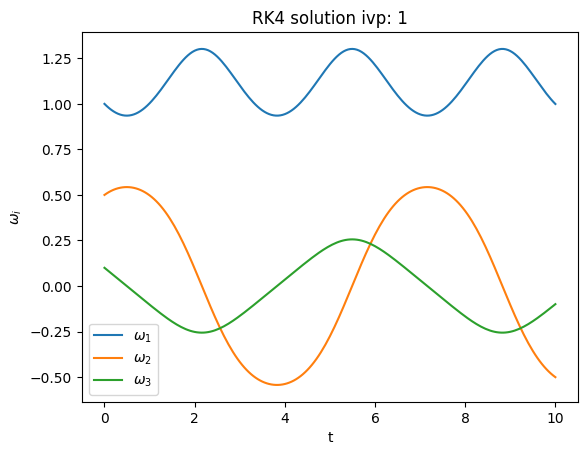

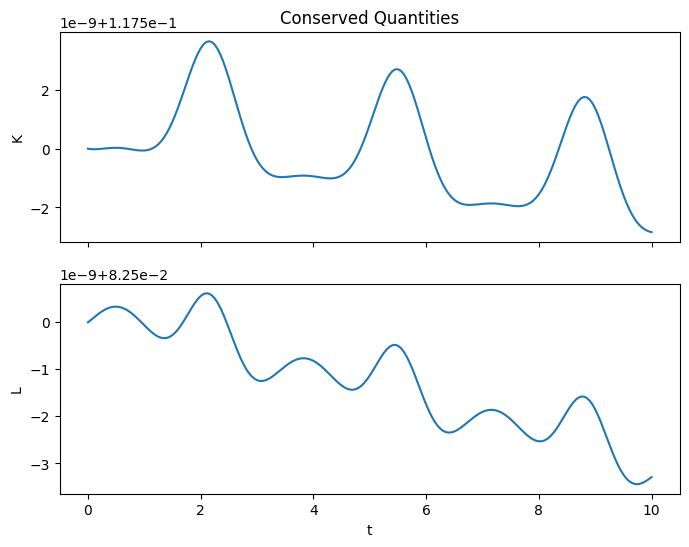

K range: 6.4978994268605206e-09
L range: 4.060761712998406e-09


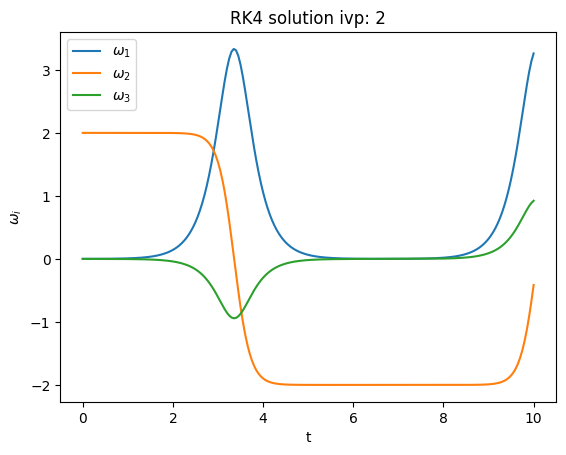

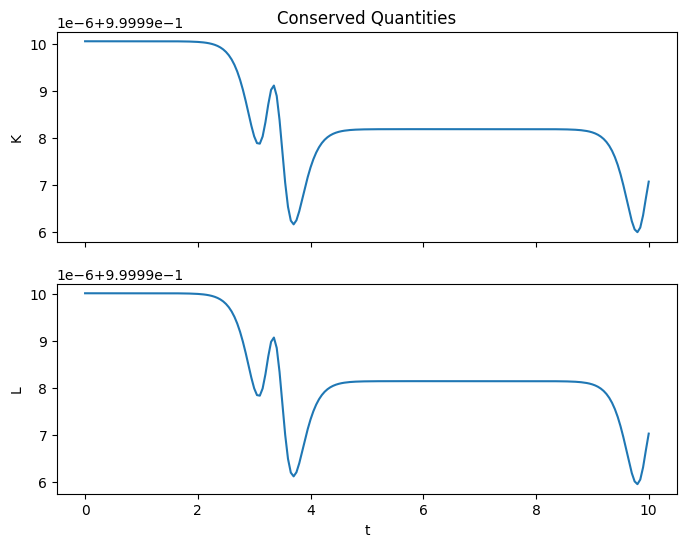

K range: 4.053681070592674e-06
L range: 4.053681937343789e-06


In [ ]:
# Workspace for Question 2(a) Code
import numpy as np
import matplotlib.pyplot as plt

def rhs(omega, a, b):
    """
    Evaluate the RHS of the coupled ODES
    """
    w1, w2, w3 = omega
    dw1 = (b-1) / a * w2 * w3
    dw2 = (1-a) / b * w3 * w1
    dw3 = (a - b) * w1 * w2
    return np.array([dw1, dw2, dw3])

def step(omega, tau, a, b):
    """
    computes one RK4 step
    """
    f1 = rhs(omega, a, b)
    f2 = rhs(omega + 0.5 * tau * f1, a, b)
    f3 = rhs(omega + 0.5 * tau * f2, a, b)
    f4 = rhs(omega + tau*f3, a, b)

    return omega + 1/6 * tau * (f1 + 2*f2 + 2*f3 + f4)

def K(omega, a, b):
    """
    compute the kinetic energy of the system
    """
    return 0.5 * a * omega[0]**2 + 0.5 * b * omega[1]**2 + 0.5 * omega[2]**2

def L(omega, a, b):
    """
    compute the magnitude of angular momentum of the system
    """
    return a**2 * omega[0]**2 + b**2 * omega[1]**2 + omega[2]**2

# initialise parameters
tau = 0.05
a = 0.1
b = 0.5
T = 10

OMEGA0 = {
    1 : np.array([1.0, 0.5, 0.1]),
    2 : np.array([1e-3, 2.0, 0.0])
}

for ivp in [1, 2]:
    # initialise vectors
    time = np.arange(0.0, T + tau, tau)

    omega_vals = np.zeros((len(time), 3))
    K_vals = np.zeros(len(time))
    L_vals = np.zeros(len(time))

    # initial vals
    omega_vals[0] = OMEGA0[ivp]
    K_vals[0] = K(omega_vals[0], a, b)
    L_vals[0] = L(omega_vals[0], a, b)

    # RK4 and compute energy at each time step
    for i in range(len(time) - 1):
        omega_vals[i+1] = step(omega_vals[i], tau, a, b)
        K_vals[i+1] = K(omega_vals[i+1], a, b)
        L_vals[i+1] = L(omega_vals[i+1], a, b)

    # plot solution
    plt.plot(time, omega_vals[:, 0], label=r"$\omega_1$")
    plt.plot(time, omega_vals[:, 1], label=r"$\omega_2$")
    plt.plot(time, omega_vals[:, 2], label=r"$\omega_3$")

    plt.title(f"RK4 solution ivp: {ivp}")
    plt.xlabel("t")
    plt.ylabel(r"$\omega_i$")
    plt.legend()

    plt.show()

    # plot energy
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

    ax1.plot(time, K_vals)
    ax1.set_ylabel('K')
    ax1.set_title('Conserved Quantities')

    ax2.plot(time, L_vals)
    ax2.set_ylabel('L')
    ax2.set_xlabel('t')

    plt.show()

    print(f"K range: {np.max(K_vals) - np.min(K_vals)}")
    print(f"L range: {np.max(L_vals) - np.min(L_vals)}")

**(b) [3 points]** Briefly explain:
1. Which case represents the flipping T-handle, and why.
2. How the solution matches what is seen in the video.
3. Whether your solutions are accurate.


<span style="color:magenta">*(Workspace for Answers)*</span>
1. The second case represents the flipping T-handle. We can see that the angular velocity $\omega_2$ steps between the values 2 and -2. This indicates the handle is flipping spin direction like we see in the video.
2. The solution seems to match very well to the video. As previously noted, we see the handle is flipping spin directions. We can also see the rotation around axes 1 and 3 occur as $\omega_2$ changes sign. This matches how we seee the handle flip from one direction to the other by spinnning its end and reflecting across the plane perpendicular to the axis of rotation (axis 2)
3. As kinetic energy and angular momentum only vary over a relatively small range (of order $10^{-6}$) we are confident in the solutions accuracy.s

### Question 3: 1-D Advection and Stability Analysis (9 points)

Consider the (non-dimensional) 1-D advection equation, which models the transport of a scalar quantity $a(x,t)$ in a medium flowing at a constant velocity $c_0$:
$$ \frac{\partial a}{\partial t} =  -c_0 \frac{\partial a}{\partial x}. \tag{11} $$

The function $$a(x,t)=f(x-c_0t), \tag{12} $$
provides a solution to Eq. (11) for the general initial value problem, where $$f(x)=a(x,0)$$ is the initial amplitude profile.

**(a) [3 points]** For the initial profile 

$$
a(x,0) = A \exp \left[-\kappa\left(x-\frac{1}{2}\right)^2\right]
\tag{13}
$$

where $A$ and $\kappa$ are constants. Sketch the profile $a(x,t)$ at time $t=0$ and at a time $t>0$.


<span style="color:magenta">*(Workspace for Answers)*</span>

**(b) [6 points]** Consider the numerical solution of Eq. (11) with the "leap-frog” scheme

$$
a_j^{\,n+1} = a_j^{\,n-1} - g\left(a_{j+1}^{\,n}-a_{j-1}^{\,n}\right),
\tag{14}
$$

where

$$
g = \frac{c_0 \tau}{h}.
$$

1. Apply von Neumann stability analysis to Eq. (14) and show that the amplification factor is

$$
\xi = - i g \sin(kh) \pm \sqrt{1 - g^2 \sin^2(kh)}.
\tag{15}
$$

You will need to solve a quadratic equation.

2.  Determine when the leap-frog scheme, Eq. (14), is unstable.

<span style="color:magenta">*(Workspace for Answers)*</span>

<span style="color:magenta">*(Workspace for Answers)*</span>